In [1]:
import pandas as pd
from sqlalchemy import create_engine
import seaborn as sns
import matplotlib.pyplot as plt
import os
from dotenv import load_dotenv

load_dotenv()
db_url = os.getenv("DATABASE_URL")
engine = create_engine(db_url)

# Проверка аномальных транзакций в январе 2026
**Описание шага:**
- Цель данного этапа — провести точечный аудит сырых данных за январь 2026 года, чтобы определить природу аномального всплеска удержания на графиках. Нам необходимо выяснить, чем вызван этот пик: технической ошибкой (дублированием логов, единичными закупками «крупных оптовиков») или реальным массовым наплывом уникальных покупателей.
- Для исследования из таблицы public.raw_transactions извлекаются все транзакции за январь 2026 года. С помощью статистического метода .describe() и подсчета уникальных значений оценивается структура распределения чеков, средний объем покупок и количество активных клиентов.

In [2]:
# Выгружаем сырые данные за аномальный январь 2026 года
january_2026_query = """
select
	client_uuid,
	trans_date::date as trans_date,
	nullif(amount,'error'):: numeric as amount,
	product_list,
	promo_code,
	channel
from public.raw_transactions
where EXTRACT(year from (trans_date::date)) = 2026
	and EXTRACT(month from (trans_date::date)) = 1
"""
df_january = pd.read_sql(january_2026_query, engine,parse_dates=['trans_date'])
df_january.head(3)

,client_uuid,trans_date,amount,product_list,promo_code,channel
0,56ae8306-1ad6-4662-90a9-9517c17dddbe,2026-01-08,14943.61,"Shorts,Jacket,Sneakers",agency,online
1,5286eafe-a53b-46e2-bb92-c453b71bb60d,2026-01-09,5942.10,Hat,NaN,online
2,d4c95140-e094-4a48-9dcf-e8b0825e2a1e,2026-01-30,7006.79,"Jacket,Tshirt,Shorts",others,NaN


In [3]:
df_january.describe()

,trans_date,amount
count,789,766.000000
mean,2026-01-16 06:52:28,7214.042650
min,2026-01-01 00:00:00,-475.220000
25%,2026-01-09 00:00:00,3288.715000
50%,2026-01-17 00:00:00,7007.605000
75%,2026-01-24 00:00:00,11510.705000
max,2026-01-31 00:00:00,14992.550000
std,NaN,4576.743998


In [4]:
unique_users = df_january['client_uuid'].nunique()
print(f'Количество уникальных клиентов: {unique_users}')

Количество уникальных клиентов: 718


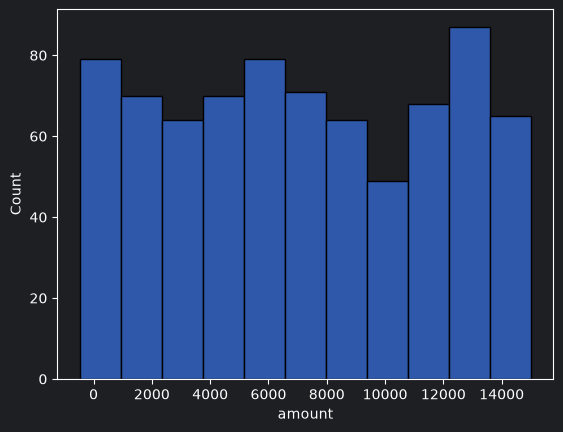

In [5]:
sns.histplot(data=df_january,x='amount')
plt.show()

## Вывод по этапу аудита:
1. Техническая чистота распределения: Разгадка январского пика найдена. Отношение общего числа транзакций (789) к числу уникальных клиентов (718) составляет (1.1). Это доказывает, что аномалия вызвана не техническим сбоем и не единичными «крупными оптовиками» (максимальный чек 14 992 руб. всего в два раза выше среднего). Январский всплеск — это реальный массовый наплыв уникальных покупателей, каждый из которых совершил ровно по одной стандартной покупке.
2. Типичный чек: Медиана (50% = 7 007 руб.) находится вплотную к среднему значению (mean = 7 214 руб.). Это говорит о симметричном, здоровом распределении данных без сильных перекосов и скрытых выбросов.
3. Обнаружение возвратов: Минимальное значение чека имеет отрицательный показатель (min = -475.22 руб.). Это указывает на наличие в сырых данных операций возврата (refunds). На этапе построения DWH необходимо заложить логику фильтрации таких строк, чтобы они не раздували уникальный числитель активных пользователей.

**Бизнес-итог**: Январь 2026 года — это период мощной сезонной активности (вероятно, постновогодняя распродажа). Она сработала как триггер, заставив одновременно вернуться за покупками клиентов из абсолютно всех исторических когорт.